# 1. Setup
## 1.1 Config + Logger import

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
# ====== Imports ======
# Config
from config_loader import CONFIG

# Logger: LoggerManager + global configuration
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = (
    CONFIG.LOGGER_MANAGER_ENABLE_FILES_LOGS_MONITORING_ONLY_FOR_ONE_LOGGER
)
LoggerManager.enable_dynamic_config_update = CONFIG.LOGGER_MANAGER_ENABLE_DYNAMIC_CONFIG_UPDATE
LoggerManager.enable_unique_logger_identifier = CONFIG.LOGGER_MANAGER_ENABLE_UNIQUE_LOGGER_IDENTIFIER

LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=getattr(logger_colors, CONFIG.LOGGER_COLORS),
    path=CONFIG.LOGGER_PATH,
    # LogLevels
    decorator_log_level=getattr(LogLevels, CONFIG.LOGGER_DECORATOR_LOG_LEVEL),
    print_log_level=getattr(LogLevels, CONFIG.LOGGER_PRINT_LOG_LEVEL),
    file_log_level=getattr(LogLevels, CONFIG.LOGGER_FILE_LOG_LEVEL),
    # Loggers Output
    print_log=CONFIG.LOGGER_PRINT_LOG,
    write_to_file=CONFIG.LOGGER_WRITE_TO_FILE,
    # Monitoring
    display_monitoring=CONFIG.LOGGER_DISPLAY_MONITORING,
    files_monitoring=CONFIG.LOGGER_FILES_MONITORING,
    file_size_unit=CONFIG.LOGGER_FILE_SIZE_UNIT,
    disk_alert_threshold_percent=CONFIG.LOGGER_DISK_ALERT_THRESHOLD_PERCENT,
    log_files_size_alert_threshold_percent=CONFIG.LOGGER_FILES_SIZE_ALERT_THRESHOLD_PERCENT,
    max_log_file_size=CONFIG.LOGGER_MAX_LOG_FILE_SIZE,
    # Placement
    identifier_max_width=CONFIG.LOGGER_IDENTIFIER_MAX_WIDTH,
    filename_lineno_max_width=CONFIG.LOGGER_FILENAME_LINENO_MAX_WIDTH,
)

## 1.2 Importing Libraries

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import math
import time

from geometry import OrientedPoint

# 2 Path Planner tests
## 2.1 Dummy Planner

In [45]:
from navigation import DummyPathPlanner, DummyPathPlannerParams


dummy_path_planner_params = DummyPathPlannerParams()
dummy_path_planner = DummyPathPlanner(dummy_path_planner_params)

### Case 1: Displacement only

In [46]:
start = OrientedPoint(0, 0, 0)
path1 = dummy_path_planner.plan_path(start=start, distance=10.0, rotation=0.0)
print("Displacement only:", path1[-1])

Displacement only: POINT (10 0), theta: 0


### Case 2: Rotation only

In [47]:
start = OrientedPoint(0, 0, 0)
path2 = dummy_path_planner.plan_path(start=start, distance=0.0, rotation=math.pi / 2)
print("Rotation only:", path2[-1])

Rotation only: POINT (0 0), theta: 1.5707963267948966


### Case 3: Displacement + Rotation

In [48]:
start = OrientedPoint(0, 0, 0)
path3 = dummy_path_planner.plan_path(start=start, distance=10.0, rotation=math.pi / 4)
print("Displacement + Rotation:", path3[-1])

Displacement + Rotation: POINT (10 0), theta: 0.7853981633974483


## 2.2 Basic Planner

In [49]:
from navigation import BasicPathPlanner, BasicPathPlannerParams, Direction

### Case 1: Forward 

In [50]:
basic_path_planner_params = BasicPathPlannerParams()
basic_path_planner = BasicPathPlanner(basic_path_planner_params)

start = OrientedPoint(0, 0, 0)
basic_path_planner.plan_path(start=start, goal=OrientedPoint(10, 0, 0))

[POINT (0 0), theta: 0, POINT (10 0), theta: 0]

### Case 2: Backward 

In [51]:
basic_path_planner_params = BasicPathPlannerParams(direction=Direction.BACKWARD)
basic_path_planner = BasicPathPlanner(basic_path_planner_params)

start = OrientedPoint(0, 0, 0)
basic_path_planner.plan_path(start=start, goal=OrientedPoint(10, 0, 0))

[POINT (0 0), theta: 3.141592653589793, POINT (10 0), theta: 3.141592653589793]

# 3. SpeedProfile tests
## 3.1 Basic SpeedProfile

## 3.2 Linear Ramped SpeedProfile

In [52]:
from navigation import BaseSpeedProfile, BasicSpeedProfile, LinearRampedSpeedProfile

In [53]:
def test_speed_profile():
    # Paramètres de test
    acceleration = 2.0    # m/s²
    max_speed = 10.0      # m/s
    deceleration = 3.0    # secondes (durée de la phase de décélération)
    
    # Création des profils
    profile_without_distance = LinearRampedSpeedProfile(acceleration, max_speed, deceleration)
    profile_with_distance = LinearRampedSpeedProfile(acceleration, max_speed, deceleration)
    
    # Distance totale pour le test en mode avec distance (peut être ajustée)
    distance = 75.0  # mètres

    # Détermination de la durée totale pour chaque profil
    # Sans distance, on prend la durée d'accélération + décélération + marge de 2 s
    t_acc = max_speed / acceleration
    t_end_without = t_acc + deceleration + 2.0

    # Pour le profil avec distance, on détermine la durée totale théorique de la trajectoire
    d_acc_full = 0.5 * max_speed**2 / acceleration
    d_decel_full = 0.5 * max_speed * deceleration
    if distance >= d_acc_full + d_decel_full:
        t_decel = deceleration
        d_cruise = distance - (d_acc_full + d_decel_full)
        t_cruise = d_cruise / max_speed
        total_time_with = t_acc + t_cruise + t_decel
    else:
        factor = (1 / (2 * acceleration) + deceleration / (2 * max_speed))
        v_peak = (distance / factor) ** 0.5
        t_acc = v_peak / acceleration
        decel_rate = max_speed / deceleration
        t_decel = v_peak / decel_rate
        total_time_with = t_acc + t_decel

    # Création des vecteurs temps
    time_steps_without = np.linspace(0, t_end_without, 500)
    time_steps_with = np.linspace(0, total_time_with, 500)

    # Calcul des vitesses pour chaque instant
    speeds_without = [profile_without_distance.get_speed(t) for t in time_steps_without]
    speeds_with = [profile_with_distance.get_speed(t, distance=distance) for t in time_steps_with]

    # Création des graphiques
    plt.figure(figsize=(12, 5))

    # Profil sans distance
    plt.subplot(1, 2, 1)
    plt.plot(time_steps_without, speeds_without, label="Sans distance")
    plt.xlabel("Temps (s)")
    plt.ylabel("Vitesse (m/s)")
    plt.title("Profil de vitesse (sans distance)")
    plt.legend()

    # Profil avec distance
    plt.subplot(1, 2, 2)
    plt.plot(time_steps_with, speeds_with, label=f"Avec distance = {distance} m", color='orange')
    plt.xlabel("Temps (s)")
    plt.ylabel("Vitesse (m/s)")
    plt.title("Profil de vitesse (avec distance)")
    plt.legend()

    plt.tight_layout()
    plt.show()


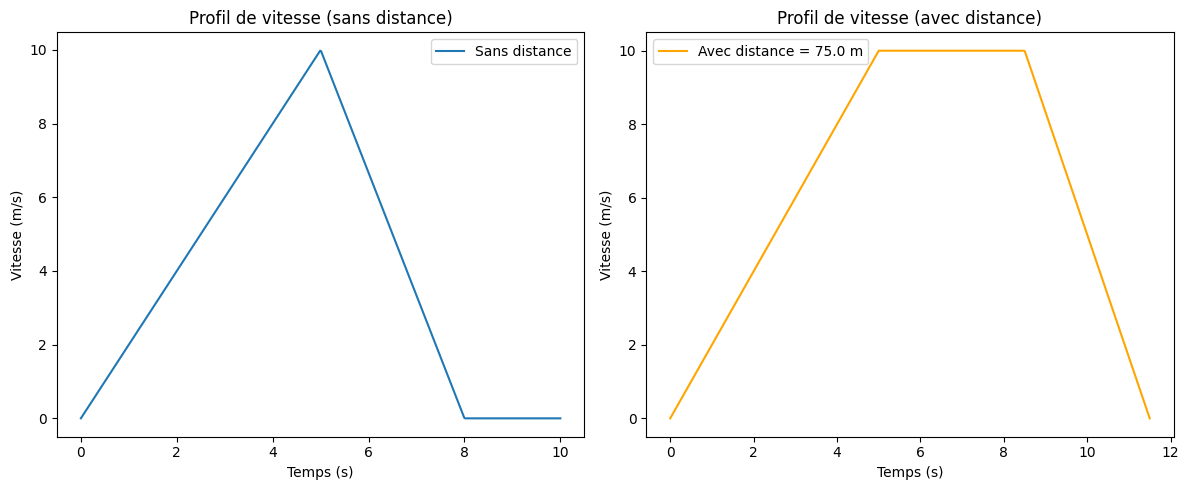

In [54]:
test_speed_profile()

# 4. Trajectory Planner tests
## 4.0 Base Trajectory Planner

In [55]:
# from navigation import BaseTrajectoryPlanner, BaseTrajectoryPlannerParams

# base_trajectory_planner_params = BaseTrajectoryPlannerParams(10.0)
# base_trajectory_planner = BaseTrajectoryPlanner(base_trajectory_planner_params)

# for i in range(5):
#     print("START")
#     base_trajectory_planner.start_planning()

#     for i in range(5):
#         base_trajectory_planner.get_plan()
#         time.sleep(0.1)
        
#     print("STOP")
#     base_trajectory_planner.stop_planning()
#     time.sleep(1.0)

## 4.1 Dummy Trajectory Planner

In [56]:
from navigation import (
    DummyTrajectoryPlanner, DummyTrajectoryPlannerParams, 
    BasicPathPlanner, BasicPathPlannerParams,
    LinearRampedSpeedProfile, BasicSpeedProfile, SpeedProfiler
)

In [57]:
trajectory_planner = DummyTrajectoryPlanner(
    DummyTrajectoryPlannerParams(), 
    SpeedProfiler(
        linear_speed_profile=LinearRampedSpeedProfile(
            acceleration=10.0, max_speed=20.0, deceleration=5.0
        ),
        angular_speed_profile=LinearRampedSpeedProfile(
            acceleration=1.0, max_speed=2.0, deceleration=0.5
        )
    )
)

In [58]:
path = [
    OrientedPoint(0, 0, 0),
    OrientedPoint(2, 1, math.pi/4),
    OrientedPoint(4, 0, math.pi/2),
    OrientedPoint(6, 3, math.pi)
]

trajectory_planner.plan_trajectory(path)
trajectory_planner.start_planning()

0.4636476090008061
-1.2490457723982544
-0.5880026035475675


In [ ]:
for segment in trajectory_planner.segments_mapper.segments:
    print(segment.)

In [59]:
angular_speeds = []
linear_speeds = []
positions = []

start_time = time.time()
while start_time + trajectory_planner.get_total_duration() > time.time():
    time.sleep(0.01)
    cmd = trajectory_planner.get_plan()

    positions.append(cmd.position)
    linear_speeds.append(cmd.linear_speed)
    angular_speeds.append(cmd.angular_speed)
    
    # Print every s
    if time.time() % 1 < 0.01:
        print(f"{int(time.time() - start_time)}/{int( trajectory_planner.get_total_duration())}")


x_positions = [pos.x for pos in positions]
y_positions = [pos.y for pos in positions]
theta_positions = [pos.theta for pos in positions]

# Création d'une figure avec plusieurs sous-graphiques
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Graphique des vitesses angulaires
axs[0, 0].plot(angular_speeds, label="Vitesse angulaire")
axs[0, 0].set_xlabel("Temps (itérations)")
axs[0, 0].set_ylabel("Vitesse angulaire")
axs[0, 0].set_title("Évolution de la vitesse angulaire")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Graphique des vitesses linéaires
axs[0, 1].plot(linear_speeds, label="Vitesse linéaire", color='r')
axs[0, 1].set_xlabel("Temps (itérations)")
axs[0, 1].set_ylabel("Vitesse linéaire")
axs[0, 1].set_title("Évolution de la vitesse linéaire")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Graphique des positions X-Y (Trajectoire) avec double axe Y
ax1 = axs[1, 0]  # Axe principal
ax2 = ax1.twinx()  # Deuxième axe Y

ax1.plot(x_positions, color='b', label="X (Position)")
ax1.plot(y_positions, color='r', label="Y (Position)")
ax1.set_ylabel("Position (cm)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2.plot(theta_positions, label="Orientation (Theta)", color='m')
ax2.set_ylabel("Orientation (theta)", color='m')
ax2.tick_params(axis='y', labelcolor='m')

ax1.set_xlabel("Temps (itérations)")
ax1.set_title("Évolution de la position X et Y")
ax1.grid(True)

# Graphique des angles Theta en fonction du temps
axs[1, 1].plot(theta_positions, label="Orientation (Theta)", color='m')
axs[1, 1].set_xlabel("Temps (itérations)")
axs[1, 1].set_ylabel("Theta (orientation)")
axs[1, 1].set_title("Évolution de l'orientation Theta")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Ajustement des espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

TypeError: '>' not supported between instances of 'complex' and 'float'

In [ ]:
def plot_path_and_simulation(path: list[OrientedPoint], simulation: list[OrientedPoint]):
    plt.figure()
    
    # Affichage de la première couche : les points du path (en bleu)
    for idx, point in enumerate(path):
        # Affichage du point
        plt.plot(point.x, point.y, 'bo', label="Path" if idx == 0 else "")
        # Calcul de l'orientation
        dx = np.cos(point.theta)
        dy = np.sin(point.theta)
        # Affichage de la flèche indiquant l'orientation
        plt.arrow(point.x, point.y, dx, dy, head_width=0.1, head_length=0.1, fc='b', ec='b')
    
    # Affichage de la deuxième couche : les points de la simulation (en rouge)
    for idx, point in enumerate(simulation):
        plt.plot(point.x, point.y, 'ro', label="Simulation" if idx == 0 else "")
        dx = np.cos(point.theta)
        dy = np.sin(point.theta)
        plt.arrow(point.x, point.y, dx, dy, head_width=0.1, head_length=0.1, fc='r', ec='r')
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Path et Simulation de Trajectoire')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

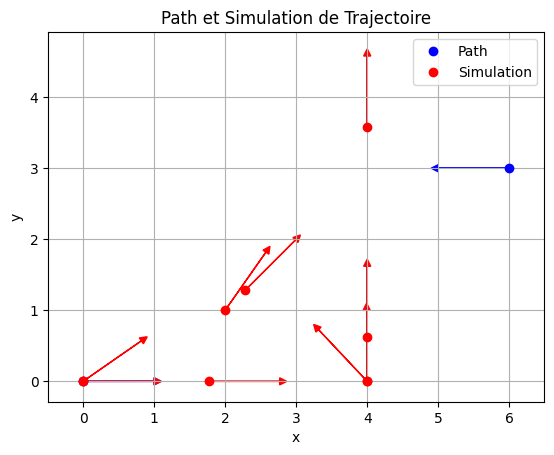

In [ ]:
plot_path_and_simulation([path[0], path[-1]], positions[::100])

## 4.2 Basic Trajectory Planner

In [ ]:
from navigation import (
    BasicTrajectoryPlanner, BasicTrajectoryPlannerParams, 
    BasicPathPlanner, BasicPathPlannerParams
)

In [ ]:
# Create a basic path
path_planner = BasicPathPlanner(BasicPathPlannerParams())
path = path_planner.plan_path(
    start=OrientedPoint(0, 0, 0), goal=OrientedPoint(10, 0, 0)
)
path

[POINT (0 0), theta: 0, POINT (10 0), theta: 0]

In [ ]:
# Create a basic trajectory planner
trajectory_planner = BasicTrajectoryPlanner(BasicTrajectoryPlannerParams(10.0, 2.0))

TypeError: BasicTrajectoryPlannerParams.__init__() takes 1 positional argument but 3 were given

In [ ]:
path = [
    OrientedPoint(0, 0, 0),
    OrientedPoint(2, 1, math.pi/4),
    OrientedPoint(4, 0, math.pi/2),
    OrientedPoint(6, 3, math.pi)
]

trajectory_planner.plan_trajectory(path)
trajectory_planner.start_planning()

0/0


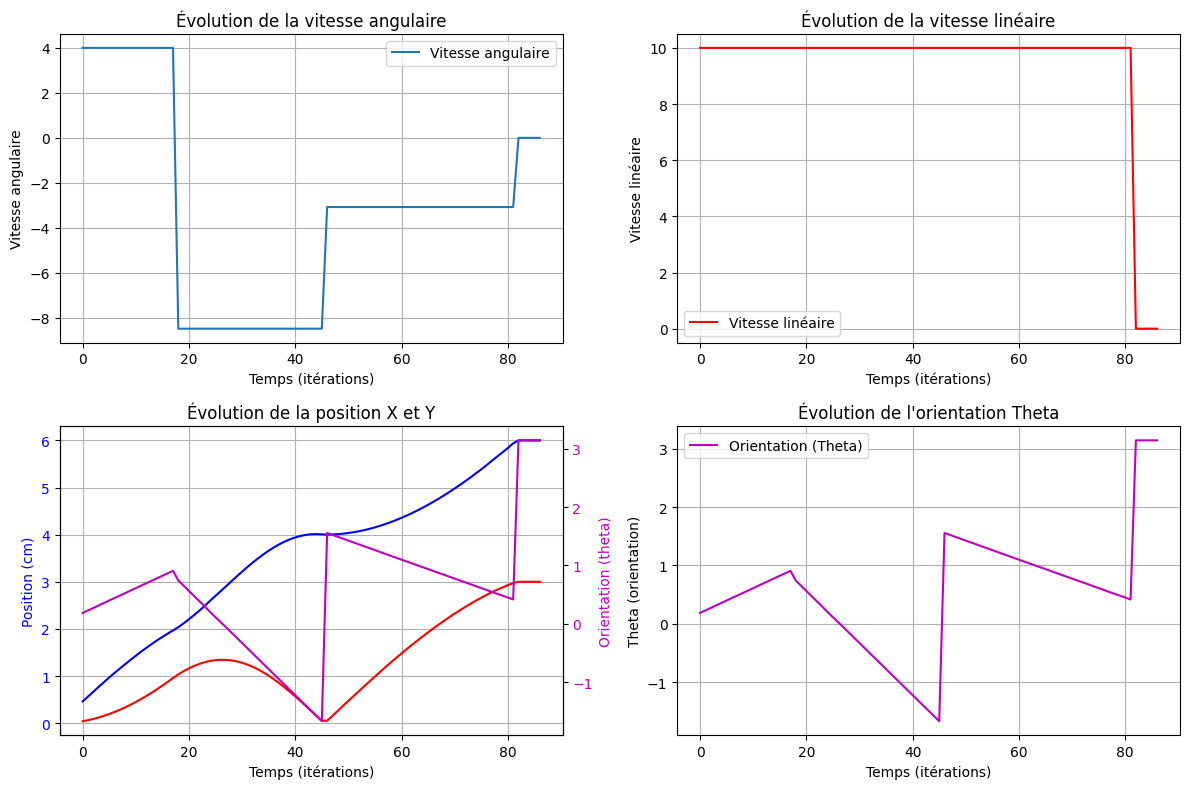

In [ ]:
angular_speeds = []
linear_speeds = []
positions = []

start_time = time.time()
while start_time + trajectory_planner.total_duration > time.time():
    time.sleep(0.01)
    cmd = trajectory_planner.get_plan()

    positions.append(cmd.position)
    linear_speeds.append(cmd.linear_speed)
    angular_speeds.append(cmd.angular_speed)
    
    # Print every s
    if time.time() % 1 < 0.01:
        print(f"{int(time.time() - start_time)}/{int( trajectory_planner.total_duration)}")


x_positions = [pos.x for pos in positions]
y_positions = [pos.y for pos in positions]
theta_positions = [pos.theta for pos in positions]

# Création d'une figure avec plusieurs sous-graphiques
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Graphique des vitesses angulaires
axs[0, 0].plot(angular_speeds, label="Vitesse angulaire")
axs[0, 0].set_xlabel("Temps (itérations)")
axs[0, 0].set_ylabel("Vitesse angulaire")
axs[0, 0].set_title("Évolution de la vitesse angulaire")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Graphique des vitesses linéaires
axs[0, 1].plot(linear_speeds, label="Vitesse linéaire", color='r')
axs[0, 1].set_xlabel("Temps (itérations)")
axs[0, 1].set_ylabel("Vitesse linéaire")
axs[0, 1].set_title("Évolution de la vitesse linéaire")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Graphique des positions X-Y (Trajectoire) avec double axe Y
ax1 = axs[1, 0]  # Axe principal
ax2 = ax1.twinx()  # Deuxième axe Y

ax1.plot(x_positions, color='b', label="X (Position)")
ax1.plot(y_positions, color='r', label="Y (Position)")
ax1.set_ylabel("Position (cm)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2.plot(theta_positions, label="Orientation (Theta)", color='m')
ax2.set_ylabel("Orientation (theta)", color='m')
ax2.tick_params(axis='y', labelcolor='m')

ax1.set_xlabel("Temps (itérations)")
ax1.set_title("Évolution de la position X et Y")
ax1.grid(True)

# Graphique des angles Theta en fonction du temps
axs[1, 1].plot(theta_positions, label="Orientation (Theta)", color='m')
axs[1, 1].set_xlabel("Temps (itérations)")
axs[1, 1].set_ylabel("Theta (orientation)")
axs[1, 1].set_title("Évolution de l'orientation Theta")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Ajustement des espacements entre les sous-graphiques
plt.tight_layout()
plt.show()

In [ ]:
def plot_path_and_simulation(path: list[OrientedPoint], simulation: list[OrientedPoint]):
    plt.figure()
    
    # Affichage de la première couche : les points du path (en bleu)
    for idx, point in enumerate(path):
        # Affichage du point
        plt.plot(point.x, point.y, 'bo', label="Path" if idx == 0 else "")
        # Calcul de l'orientation
        dx = np.cos(point.theta)
        dy = np.sin(point.theta)
        # Affichage de la flèche indiquant l'orientation
        plt.arrow(point.x, point.y, dx, dy, head_width=0.1, head_length=0.1, fc='b', ec='b')
    
    # Affichage de la deuxième couche : les points de la simulation (en rouge)
    for idx, point in enumerate(simulation):
        plt.plot(point.x, point.y, 'ro', label="Simulation" if idx == 0 else "")
        dx = np.cos(point.theta)
        dy = np.sin(point.theta)
        plt.arrow(point.x, point.y, dx, dy, head_width=0.1, head_length=0.1, fc='r', ec='r')
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Path et Simulation de Trajectoire')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

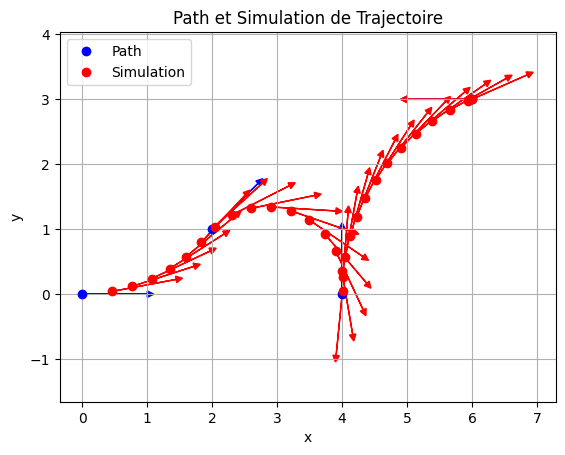

In [ ]:
plot_path_and_simulation(path, positions[::3])